# Cloud-Optimized LiDAR: Processing & Visualization Tutorial

### Authors
1. **Dr. Rajat Shinde** (rajat.shinde@uah.edu) – NASA IMPACT / University of Alabama in Huntsville  
2. **Dr. Alex Mandel** (alex@developmentseed.org) – Development Seed  
3. **Chuck Daniels** (chuck@developmentseed.org) – Development Seed  

### Acknowledgments
NASA-ESA **Multi-Mission Algorithm and Analysis Platform (MAAP)** Science Working Group  
- **Dr. Laura Duncanson**, **Dr. David Minor**, **Dr. Neha Hunka**, **Paromita Basak**

### Additional Support
Jamison French, Sheyenne Kirkland, Dr. Brian M. Freitag (NASA), Kyle Barron (Lonboard),  
Sanjay Bhangar, Yuvi Panda (NotebookSharing.space), Rob Tapella (NASA JPL), NASA-ESA MAAP Team

---

### **About This Tutorial**
This tutorial demonstrates a **cloud-native LiDAR processing workflow** using:  
- **Cloud-Optimized Point Clouds (COPCs)** & **Cloud-Optimized GeoTIFFs (COGs)**  
- [**Lonboard**](https://developmentseed.org/lonboard/latest/) for interactive visualization  
- [**TiTiler**](https://developmentseed.org/titiler/) for dynamic tiling  
- [**PDAL**](https://pdal.io/) for LiDAR processing  

We use **Airborne LiDAR Scanning (ALS)** data from **Panama’s Barro Colorado Island (BCI)**, a Smithsonian STRI research site, along with **Above-Ground Biomass (AGB)** estimates and [**Meta’s Canopy Height Model (CHM)**](https://www.sciencedirect.com/science/article/pii/S003442572300439X?via%3Dihub).  

---

### **Workflow Overview**

1. **Part 1 – LAS → COPC Conversion**  
   - Learn to convert raw LAS files into **COPCs** for efficient streaming.

2. **Part 2 – Benchmarking LAS vs COPC**  
   - Compare **processing time** and **points processed** for subsetting → *How much faster is COPC?*

3. **Part 3 – Canopy Height Model (CHM)**  
   - Generate a CHM from both LAS and COPC → *Same science result, but faster with COPC!*

4. **Part 4 – Interactive Visualization (Lonboard & TiTiler)**  
   - Visualize COPCs, CHMs, and AGB maps directly from the cloud → *Stream data without full downloads.*

---

### **Why This Matters?**
- **Science Examples:**  
  - Quickly explore **forest structure** in tropical forests.  
  - Integrate CHMs with AGB for biomass estimation.  
  - Prepare scalable workflows for **large LiDAR archives**.  

- **Curiosity Questions to Consider:**  
  - How much time can you save using COPCs over LAS?  
  - Can cloud-native workflows make massive LiDAR datasets accessible to everyone?  
  - What new science questions can you answer if visualization is near-instant?

---

### **Additional Resources**
1. [Lonboard](https://developmentseed.org/lonboard/latest/)  
2. [TiTiler](https://developmentseed.org/titiler/)  
3. [LAS → COPC Conversion Guide](https://guide.cloudnativegeo.org/copc/lidar-las-to-copc.html)  
4. [Cloud-Optimized GeoTIFFs](https://guide.cloudnativegeo.org/cloud-optimized-geotiffs/intro.html)  
5. [Barro Colorado Island (STRI)](https://stri.si.edu/facility/barro-colorado)  
6. [MAAP Project](https://maap-project.org/)


## Environment

The packages needed for this notebook can be installed with `conda` or `mamba`. Using the `environment.yml` [from this folder](./environment.yml) run:

```bash
conda env create -f environment.yml
```

or

```bash
mamba env create -f environment.yml
```

Finally, you may activate and select the kernel in the notebook (running in Jupyter)

```bash
conda activate cloud-optimized-lidar
```

The notebook has been tested to work with the listed Conda environment.

## Setup

This tutorial will explore how to-

1. Read a LiDAR LAS file using PDAL in Python
2. Convert the LiDAR LAS file to Cloud-Optimized Point Cloud (COPC) format
2. Validate the generated COPC file

## About the Dataset

We will be using the [G-LiHT Lidar Point Cloud V001](http://doi.org/10.5067/Community/GLIHT/GLLIDARPC.001) from the NASA EarthData. To access NASA EarthData in Jupyter you need to register for an [Earthdata account](https://urs.earthdata.nasa.gov/users/new).

We will use [earthaccess](https://github.com/nsidc/earthaccess) library to set up credentials to fetch data from NASA's EarthData catalog.

In [1]:
import earthaccess
import os
import pdal

In [2]:
earthaccess.login()

## Creating a Data Directory for this Tutorial

We are creating a data directory for downloading all the required files locally. 

In [3]:
# set data directory path
data_dir = './data'

# check if directory exists -> if directory doesn't exist, directory is created
if not os.path.exists(data_dir):
    os.mkdir(data_dir)

## Downloading the Dataset from EarthData

We are using `search_data` method from the `earthaccess` module for searching the Granules from the selected collection. The `temporal` argument defines the temporal range for 

In [4]:
# Search Granules

las_item_results = earthaccess.search_data(
    short_name="GLLIDARPC",
    version="001",
    temporal = ("2020"), 
    count=3
)

In [5]:
las_item_results

[Collection: {'ShortName': 'GLLIDARPC', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -80.93942516163676, 'Latitude': 25.26716090650648}, {'Longitude': -80.93498859506009, 'Latitude': 25.267159019323177}, {'Longitude': -80.93498377915554, 'Latitude': 25.276198715138406}, {'Longitude': -80.93942067438299, 'Latitude': 25.276200603090036}, {'Longitude': -80.93942516163676, 'Latitude': 25.26716090650648}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2020-03-11T04:00:00.000Z', 'EndingDateTime': '2020-03-12T03:59:59.000Z'}}
 Size(MB): 35.3623
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/GLLIDARPC.001/GLLIDARPC_FL_20200311_FIA8_l0s21/GLLIDARPC_FL_20200311_FIA8_l0s21.las'],
 Collection: {'ShortName': 'GLLIDARPC', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -80.92108766304484,

Let's use the file with size 91.04 MB and convert it to a COPC format. 

In [6]:
# Download Data - Selecting the 3rd file from the `las_item_results` list
gliht_las_file = earthaccess.download(las_item_results[2], data_dir)
las_filename = gliht_las_file[0]
print(las_filename)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

data/GLLIDARPC_FL_20200311_FIA8_l0s30.las


## A Brief Introduction to PDAL 

[PDAL](https://pdal.io/) (Point Data Abstraction Library) is a C/C++ based open-source library for processing point cloud data. Additionally, it also has a PDAL-Python wrapper to work in a Pythonic environment. 

#### Accessing and Getting Metadata Information

PDAL CLI provides multiple [applications](https://pdal.io/en/2.7.0/apps/index.html) for processing point clouds. Also, it allows chaining of these applications for processing point clouds. Similar to `gdal info` for TIFFs, we can run `pdal info <filename>` on the command line for getting metadata from a point cloud file without reading it in memory.  

In [7]:
!pdal info {las_filename}

{
  "file_size": 68798163,
  "filename": "data/GLLIDARPC_FL_20200311_FIA8_l0s30.las",
  "now": "2025-07-22T15:08:52-0700",
  "pdal_version": "2.8.4 (git-version: 156082)",
  "reader": "readers.las",
  "stats":
  {
    "bbox":
    {
      "EPSG:4326":
      {
        "bbox":
        {
          "maxx": -80.94944015,
          "maxy": 25.35756378,
          "maxz": 70.02,
          "minx": -80.95497801,
          "miny": 25.34852239,
          "minz": -11.84
        },
        "boundary": { "type": "Polygon", "coordinates": [ [ [ -80.954978014258103, 25.348524181932824, -11.84 ], [ -80.954974666861602, 25.357563781023941, -11.84 ], [ -80.949440145627236, 25.357561984567131, 70.02 ], [ -80.949443904485847, 25.348522386205381, 70.02 ], [ -80.954978014258103, 25.348524181932824, -11.84 ] ] ] }
      },
      "native":
      {
        "bbox":
        {
          "maxx": 505087.1163,
          "maxy": 2804541.993,
          "maxz": 70.02,
          "minx": 504530.2563,
          "miny": 28035



#### PDAL Pipelines

For converting the LiDAR LAS file to COPC format, we will define a [pdal pipeline](https://pdal.io/en/latest/pipeline.html). A pipeline defines data processing within pdal for reading (using [pdal readers](https://pdal.io/en/latest/stages/readers.html)), processing (using [pdal filters](https://pdal.io/en/latest/stages/filters.html)) and writing operations (using [pdal writers](https://pdal.io/en/latest/stages/writers.html)). The pipelines can also represent sequential operations and can be executed as [_stages_](https://pdal.io/en/latest/pipeline.html#stage-object).

A pdal pipeline is defined in a JSON format either as a JSON object or a JSON array. Below is an example of a pdal pipeline taking a `.las` file as input, generating `stats` and writing it to a COPC format. 

```json
{
  "pipeline": [
    {
        "filename":las_filename,
        "type":"readers.las"
    },
    {
        "type":"filters.stats",
    },
    {
        "type":"writers.copc",
        "filename":copc_filename
    }
]
}
```

This pipeline can be executed using the `pdal pipeline <path_to_json_file>` from the command line for a pipeline saved as a local `JSON` file. 

#### Programmatic Pipeline Construction

However, here we will explore a comparatively easier and Pythonic approach to define a pipeline and execute it. This is based on the [PDAL Python extension](https://pypi.org/project/pdal/) which provides a programmatic pipeline construction approach in addition to the simple pipeline construction approach discussed above. 

This approach utilizes the `|` operator to pipe various stages together representing a pipeline. For eg., the above pipeline can be represented as -

```python
pipeline = pdal.Reader.las(filename=las_filename) | pdal.Writer.copc(filename=copc_filename) | pdal.Filter.stats()
```
This pipeline can be executed using `pipeline.execute`.

## LAS to COPC Conversion

Now, let's dive into converting the LAS file to a COPC format based on the programmatic pipeline construction.  

In [8]:
# Defining output filename. Usually, COPC files are saved as .copc.laz
copc_filename = las_filename.replace('.las', '.copc.laz')
copc_filename

'data/GLLIDARPC_FL_20200311_FIA8_l0s30.copc.laz'

In [9]:
# pipe = stage 1 | stage 2 | stage 3
# Or, pipeline = pipeline 1 | stage 2

# Once the pipeline is executed successfully, it prints the count of number of points
pipe = pdal.Reader.las(filename=las_filename) | pdal.Writer.copc(filename=copc_filename)
pipe.execute()

2457063

## Validation

As we can see from output of the below cell, the `.copc.laz` file is created in the destination directory.

In [10]:
# using -go for removing user details and h for getting memory size in MBs
!ls -goh ./data

total 84M
-rw-r--r-- 1 19M Jul 22 15:08 GLLIDARPC_FL_20200311_FIA8_l0s30.copc.laz
-rw-r--r-- 1 66M Jul 22 15:08 GLLIDARPC_FL_20200311_FIA8_l0s30.las


Let's read the created COPC file again and check the value of `copc` flag from the [metadata](https://pdal.io/en/latest/development/metadata.html). If the generated LiDAR file is a valid COPC file, then this flag should be set to `True`.

In [11]:
valid_pipe = pdal.Reader.copc(filename=copc_filename) | pdal.Filter.stats()
valid_pipe.execute()

# Getting value for the "copc" key under the metadata
# Output is True for a valid COPC
value = valid_pipe.metadata["metadata"]["readers.copc"].get("copc")
print(value)

True


## Accessing Data

The data values can be accessed from the executed pipeline using `valid_pipe.arrays`. The values in the arrays represent the LiDAR point cloud attributes such as `X`, `Y`, `Z`, and `Intensity`, etc.

In [12]:
arr_values = valid_pipe.arrays

# Print the array values as a dataframe
print(arr_values)

[array([(504930.99, 2804416.87, 2.58, 34078, 2, 2, 1, 0, 1, 0, 0, 0, 0, 31.998, 1, 208, 310605.47171127, 0),
       (504927.2 , 2804416.91, 2.37, 24247, 2, 3, 1, 0, 1, 0, 0, 0, 0, 31.002, 1, 192, 310605.47834322, 0),
       (504928.56, 2804417.16, 0.84, 37595, 1, 1, 1, 0, 1, 0, 0, 0, 0, 31.002, 1,  51, 310605.47834654, 0),
       ...,
       (504789.51, 2804291.19, 0.03, 25973, 1, 1, 0, 0, 2, 0, 0, 0, 0,  6.   , 2,   0, 310603.78770948, 0),
       (504782.4 , 2804290.29, 0.23, 37879, 1, 1, 0, 0, 2, 0, 0, 0, 0,  4.998, 2,   0, 310603.7877784 , 0),
       (504785.2 , 2804291.06, 0.23, 40304, 1, 1, 0, 0, 2, 0, 0, 0, 0,  6.   , 2,   0, 310603.79440971, 0)],
      shape=(2457063,), dtype=[('X', '<f8'), ('Y', '<f8'), ('Z', '<f8'), ('Intensity', '<u2'), ('ReturnNumber', 'u1'), ('NumberOfReturns', 'u1'), ('ScanDirectionFlag', 'u1'), ('EdgeOfFlightLine', 'u1'), ('Classification', 'u1'), ('Synthetic', 'u1'), ('KeyPoint', 'u1'), ('Withheld', 'u1'), ('Overlap', 'u1'), ('ScanAngleRank', '<f4'), ('U

Similarly, we can get COPC file `statistic` and `log` from the executed pipeline using `valid_pipe.metadata["metadata"]["filters.stats"]["statistic"]` and `valid_pipe.log`. The readers are encouraged to explore the results of these operations on their own. 

In [13]:
# Getting statistic from the metadata
valid_pipe.metadata["metadata"]["filters.stats"]["statistic"]

[{'average': 504816.7788,
  'count': 2457063,
  'maximum': 505087.12,
  'minimum': 504530.26,
  'name': 'X',
  'position': 0,
  'stddev': 115.1595999,
  'variance': 13261.73345},
 {'average': 2804030.972,
  'count': 2457063,
  'maximum': 2804541.99,
  'minimum': 2803541,
  'name': 'Y',
  'position': 1,
  'stddev': 283.2236743,
  'variance': 80215.64968},
 {'average': 1.042617002,
  'count': 2457063,
  'maximum': 70.02,
  'minimum': -11.84,
  'name': 'Z',
  'position': 2,
  'stddev': 0.9179675991,
  'variance': 0.842664513},
 {'average': 31772.45759,
  'count': 2457063,
  'maximum': 65535,
  'minimum': 14286,
  'name': 'Intensity',
  'position': 3,
  'stddev': 5683.856168,
  'variance': 32306220.94},
 {'average': 1.103245216,
  'count': 2457063,
  'maximum': 4,
  'minimum': 1,
  'name': 'ReturnNumber',
  'position': 4,
  'stddev': 0.3136383408,
  'variance': 0.09836900885},
 {'average': 1.206380138,
  'count': 2457063,
  'maximum': 4,
  'minimum': 1,
  'name': 'NumberOfReturns',
  'posi

## Part 2: Benchmarking LAS vs COPC
_This section demonstrates why Cloud-Optimized Point Clouds (COPC) are more efficient for LiDAR analytics._

We compare the performance of:
- **Standard LAS/LAZ files** (entire file must be downloaded and processed locally), and  
- **Cloud-Optimized Point Clouds (COPC)** (only required spatial subsets are streamed on demand).

### What You’ll Learn:
- How to measure **processing time** for subsetting a region of interest.
- How to compare the **number of points processed**, illustrating how COPC avoids unnecessary data reads.
- Why COPC is ideal for **cloud-native workflows** where bandwidth and processing efficiency are critical.


In [39]:
import os, time, requests, json, pdal

# LAS URL (MAAP S3 public equivalent)
LAS_URL = "https://nasa-maap-data-store.s3.us-west-2.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_Data___2/usa_neonsrer_2019_NEON_D14_SRER_DP1_L088-1_2019091314_unclassified_point_cloud_0000001.las"
LOCAL_LAS = f"data/{LAS_URL.split('/')[-1]}"

BBOX = "([626102.495,626177.495],[1011902.495,1011977.495],[-9999,9999])"

# ----------------------------
# LAS: Download + Process Combined
# ----------------------------
start_total_las = time.time()

# Download if not already present
with open(LOCAL_LAS, "wb") as f:
    f.write(requests.get(LAS_URL).content)

# Process locally
las_pipeline = {
    "pipeline": [
        {"type": "readers.las", "filename": LOCAL_LAS},
        {"type": "filters.crop", "bounds": BBOX}
    ]
}
p = pdal.Pipeline(json.dumps(las_pipeline))
p.execute()

las_total_time = time.time() - start_total_las
las_points = p.metadata["metadata"]["readers.las"]["count"]

print("\n=== LAS Benchmark ===")
print(f"LAS Total (Download + Process) Time : {las_total_time:.2f} s")
print(f"LAS Points Processed               : {las_points}")


=== LAS Benchmark ===
LAS Total (Download + Process) Time : 4.36 s
LAS Points Processed               : 6999009


In [40]:
# COPC URL (Streaming)
COPC_URL = "https://nasa-maap-data-store.s3.us-west-2.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809682010602.copc.laz"

# ----------------------------
# COPC: Access + Process Combined
# ----------------------------
start_copc = time.time()

copc_pipeline = {
    "pipeline": [
        {"type": "readers.copc", "filename": COPC_URL},
        {"type": "filters.crop", "bounds": BBOX}
    ]
}
p2 = pdal.Pipeline(json.dumps(copc_pipeline))
p2.execute()

copc_total_time = time.time() - start_copc
copc_points = p2.metadata["metadata"]["readers.copc"]["count"]

print("\n=== COPC Benchmark ===")
print(f"COPC Total (Access + Process) Time : {copc_total_time:.2f} s")
print(f"COPC Points Processed              : {copc_points}")


=== COPC Benchmark ===
COPC Total (Access + Process) Time : 3.13 s
COPC Points Processed              : 3012539


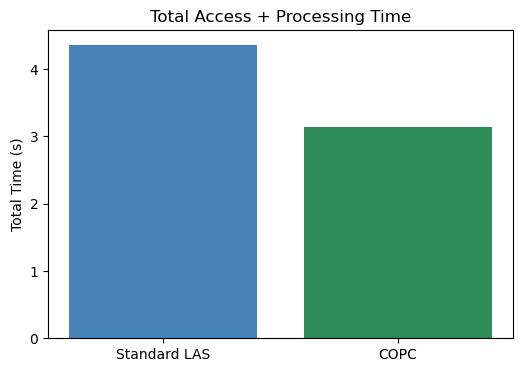

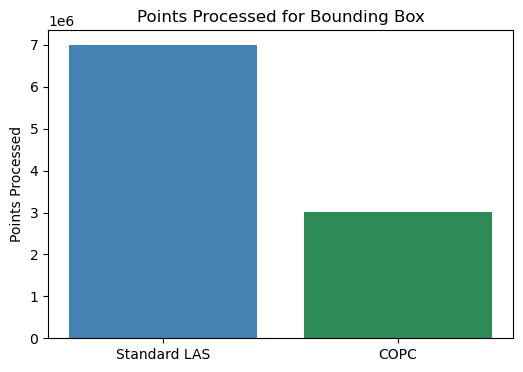

In [41]:
import matplotlib.pyplot as plt

methods = ['Standard LAS', 'COPC']
total_times = [las_total_time, copc_total_time]
points = [las_points, copc_points]

# ----------------------------
# 1. Total Access + Processing Time
# ----------------------------
plt.figure(figsize=(6, 4))
plt.bar(methods, total_times, color=['steelblue', 'seagreen'])
plt.ylabel('Total Time (s)')
plt.title('Total Access + Processing Time')
plt.show()

# ----------------------------
# 2. Points Processed
# ----------------------------
plt.figure(figsize=(6, 4))
plt.bar(methods, points, color=['steelblue', 'seagreen'])
plt.ylabel('Points Processed')
plt.title('Points Processed for Bounding Box')
plt.show()

As observed from the benchmark, COPC enables direct cloud-based access, streaming only the points within the specified bounding box. In contrast, LAS requires downloading the entire file locally and processing all points, regardless of spatial extent.

For large LiDAR archives, this difference scales significantly—COPC dramatically reduces data transfer, storage requirements, and processing time, making it far more suitable for cloud-native, on-demand analytics.

## Part 3: Canopy Height Model (CHM)
_This section shows how to derive a basic scientific product from LiDAR data._

We generate a **Canopy Height Model (CHM)** using PDAL for both **Standard LAS** and **COPC** files.  
This highlights that COPC can deliver the **same scientific results** while being **faster and more efficient** to process.

### LAS Analysis

In [54]:
import os, time, requests, json, pdal

# ----------------------------
# LAS URL (public S3 or MAAP equivalent)
# ----------------------------
LAS_URL = "https://nasa-maap-data-store.s3.us-west-2.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_Data___2/usa_neonsrer_2019_NEON_D14_SRER_DP1_L088-1_2019091314_unclassified_point_cloud_0000001.las"
LOCAL_LAS = f"data/{LAS_URL.split('/')[-1]}"

# ----------------------------
# Fresh Download Every Time (overwrite if exists)
# ----------------------------
print("Downloading LAS file")
start_download = time.time()
with open(LOCAL_LAS, "wb") as f:
    f.write(requests.get(LAS_URL).content)
download_time_las = time.time() - start_download
print("File downloaded")

File downloaded


In [55]:
# ----------------------------
# Dynamic BBox from LAS Metadata
# ----------------------------
metadata_pipeline_las = {
    "pipeline": [
        {"type": "readers.las", "filename": LOCAL_LAS},
        {"type": "filters.info"}
    ]
}
p_meta_las = pdal.Pipeline(json.dumps(metadata_pipeline_las))
p_meta_las.execute()

meta_las = p_meta_las.metadata["metadata"]["readers.las"]
center_x_las = (meta_las["minx"] + meta_las["maxx"]) / 2
center_y_las = (meta_las["miny"] + meta_las["maxy"]) / 2

distance = 100  # ~100m x 100m
new_minx_las = center_x_las - distance / 2
new_maxx_las = center_x_las + distance / 2
new_miny_las = center_y_las - distance / 2
new_maxy_las = center_y_las + distance / 2

BBOX_LAS = f"([{new_minx_las},{new_maxx_las}],[{new_miny_las},{new_maxy_las}],[-9999,9999])"
print("Dynamic LAS BBox:", BBOX_LAS)

Dynamic LAS BBox: ([509645.95,509745.95],[3516770.745,3516870.745],[-9999,9999])


In [57]:
# ----------------------------
# CHM Generation (LAS)
# ----------------------------
pdal_chm_pipeline_las = {
    "pipeline": [
        {"type": "readers.las", "filename": LOCAL_LAS},
        {"type": "filters.crop", "bounds": BBOX_LAS},
        {"type": "filters.smrf"},
        {"type": "filters.hag_delaunay"},
        {
            "type": "writers.gdal",
            "resolution": 1.0,
            "filename": "standard_chm.tif",
            "output_type": "max"
        }
    ]
}

start_chm = time.time()
p_las = pdal.Pipeline(json.dumps(pdal_chm_pipeline_las))
p_las.execute()
chm_time_las = time.time() - start_chm + download_time_las  # include download

las_points = p_las.metadata["metadata"]["readers.las"]["count"]
chm_time_per_point_las = chm_time_las / las_points

# ----------------------------
# Print LAS CHM Benchmark
# ----------------------------
print("\n=== CHM Benchmark (Standard LAS) ===")
print(f"Download + CHM Total Time : {chm_time_las:.2f} s")
print(f"Points Processed          : {las_points}")


=== CHM Benchmark (Standard LAS) ===
Download + CHM Total Time : 4.38 s
Points Processed          : 6999009


### COPC Analysis

In [58]:
# ----------------------------
# Get COPC Metadata
# ----------------------------
metadata_pipeline_copc = {
    "pipeline": [
        {"type": "readers.copc", "filename": COPC_URL},
        {"type": "filters.info"}
    ]
}
p_meta_copc = pdal.Pipeline(json.dumps(metadata_pipeline_copc))
p_meta_copc.execute()

meta_copc = p_meta_copc.metadata["metadata"]["readers.copc"]

minx_copc, maxx_copc = meta_copc["minx"], meta_copc["maxx"]
miny_copc, maxy_copc = meta_copc["miny"], meta_copc["maxy"]

# ----------------------------
# Compute a Centered BBox
# ----------------------------
center_x_copc = (minx_copc + maxx_copc) / 2
center_y_copc = (miny_copc + maxy_copc) / 2

distance = 100  # adjust as needed (100m x 100m)
new_minx_copc = center_x_copc - distance / 2
new_maxx_copc = center_x_copc + distance / 2
new_miny_copc = center_y_copc - distance / 2
new_maxy_copc = center_y_copc + distance / 2

BBOX_COPC = f"([{new_minx_copc},{new_maxx_copc}],[{new_miny_copc},{new_maxy_copc}],[-9999,9999])"
print("Dynamic COPC BBox:", BBOX_COPC)


Dynamic COPC BBox: ([553348.5359,553448.5359],[5287898.335,5287998.335],[-9999,9999])


In [61]:
pdal_chm_pipeline_copc = {
    "pipeline": [
        {"type": "readers.copc", "filename": COPC_URL},
        {"type": "filters.crop", "bounds": BBOX_COPC},
        {"type": "filters.smrf"},
        {"type": "filters.hag_delaunay"},
        {
            "type": "writers.gdal",
            "resolution": 1.0,
            "filename": "copc_chm.tif",
            "output_type": "max"
        }
    ]
}

start = time.time()
p2 = pdal.Pipeline(json.dumps(pdal_chm_pipeline_copc))
p2.execute()

chm_time_copc = time.time() - start
copc_points = p2.metadata["metadata"]["readers.copc"]["count"]
chm_time_per_point_copc = chm_time_copc / copc_points

print("\n=== CHM Benchmark (COPC) ===")
print(f"CHM Total Time       : {chm_time_copc:.2f} s")
print(f"Points Processed     : {copc_points}")



=== CHM Benchmark (COPC) ===
CHM Total Time       : 5.07 s
Points Processed     : 3012539


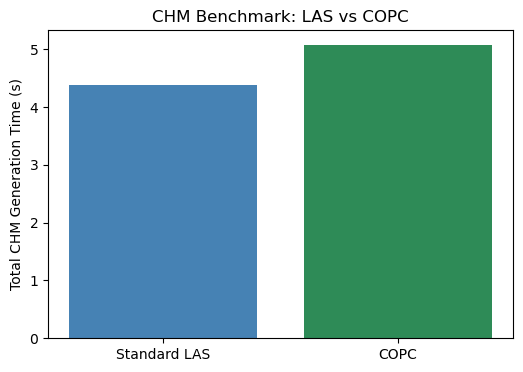

In [63]:
import matplotlib.pyplot as plt

methods = ["Standard LAS", "COPC"]
total_times = [chm_time_las, chm_time_copc]
points = [las_points, copc_points]
time_per_points = [chm_time_per_point_las, chm_time_per_point_copc]

plt.figure(figsize=(6,4))
plt.bar(methods, total_times, color=['steelblue','seagreen'])
plt.ylabel("Total CHM Generation Time (s)")
plt.title("CHM Benchmark: LAS vs COPC")
plt.show()

## Part 4: Interactive Visualization (Lonboard & TiTiler)
_Visual exploration of LiDAR data using cloud-native tools._

We use **Lonboard** and **TiTiler** to interactively visualize COPC point clouds and derived products (e.g., CHM) directly from cloud storage.  
This demonstrates how **cloud-native visualization** enables rapid exploration without downloading full datasets.

### Importing Packages

We import the required packages for this tutorial.

In [64]:
%%capture

import geopandas as gpd
from lonboard import viz
import pdal
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lonboard import Map, BitmapLayer, BitmapTileLayer, PointCloudLayer, PolygonLayer
from lonboard.colormap import apply_continuous_cmap
import httpx
import json
from palettable.colorbrewer.sequential import YlGnBu_7, Greens_3
from palettable.colorbrewer.diverging import Spectral_9
from matplotlib.colors import Normalize

Next, we define the path to the ALS LiDAR file in COPC format to be visualized.

In [65]:
in_file = "s3://maap-ops-workspace/shared/omshinde23/norm_chunk.copc.laz"

In [66]:
import boto3
from botocore.config import Config

# Set the AWS region
REGION = "us-west-2"

# Configure a boto3 session with the specified region
session = boto3.Session(region_name=REGION)

### Reading the COPC file

We read the COPC file using the PDAL python package. PDAL processes point cloud data by executing pipelines comprising of various operations (separated by `|` below). For more details, the readers are recommended to follow [Converting LiDAR LAS Files to Cloud-Optimized Point Clouds (COPCs)](https://guide.cloudnativegeo.org/copc/lidar-las-to-copc.html).

### Subsetting based on a Bounding box

Also, we crop a subset of points by using a spatial filter based on `x` and `y` coordinates, thus reducing the number of points for visualization to save memory.

In [67]:
# Crop the LiDAR file based on spatial bounds using filter.crop 
new_minx, new_maxx = 626139.995 - 37.5, 626139.995 + 37.5
new_miny, new_maxy = 1011939.995 - 37.5, 1011939.995 + 37.5

bounds = f"([{new_minx},{new_maxx}],[{new_miny},{new_maxy}],[-9999,9999])"
print(bounds)

pipeline = (pdal.Reader.copc(filename=in_file) | pdal.Filter.crop(bounds=bounds))
pipeline.execute()

([626102.495,626177.495],[1011902.495,1011977.495],[-9999,9999])


381883

### Getting the Data Values

The data values from an executed pipeline are retrieved by calling the `arrays` method.

In [68]:
# Getting array values
arr_values = pipeline.arrays

### Creating Geo-dataframe

Now, we will create a data frame followed by a Geo-dataframe based on the data values. Lonboard requires the vector data as Geo-dataframe for visualization.

In [69]:
df = pd.DataFrame(arr_values[0])

In [70]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.X, df.Y, z=df.Z), crs="32617")

Also, Lonboard requires the Geo-dataframe to have its Spatial Reference System (SRS) as World Geodetic System 1984 (WGS 84). So, we re-project the geo-dataframe to `EPSG 4326`, which is the unique reference code for WGS 84.

In [71]:
gdf_proj = gdf.to_crs(4326)
gdf_proj.head()

,X,Y,Z,Intensity,ReturnNumber,NumberOfReturns,ScanDirectionFlag,EdgeOfFlightLine,Classification,Synthetic,...,Overlap,ScanAngleRank,UserData,PointSourceId,GpsTime,ScanChannel,TargetThick,DevRatio,Zref,geometry
0,626177.27,1011907.04,17.91,8,5,5,0,1,1,0,...,0,-31.488001,1,15,3.691531e+08,0,0.224,0.9,164.64,POINT Z (-79.85162 9.15244 17.91)
1,626177.32,1011908.07,18.21,16,4,4,0,0,1,0,...,0,-31.427999,1,15,3.691531e+08,0,0.104,0.9,164.93,POINT Z (-79.85162 9.15245 18.21)
2,626177.20,1011907.77,18.27,26,4,4,0,1,1,0,...,0,-31.452000,1,15,3.691531e+08,0,0.168,1.1,164.99,POINT Z (-79.85163 9.15245 18.27)
3,626177.35,1011908.23,19.03,14,3,4,0,0,1,0,...,0,-31.452000,1,15,3.691531e+08,0,0.056,1.1,165.75,POINT Z (-79.85162 9.15245 19.03)
4,626177.10,1011908.43,18.87,15,3,3,0,0,1,0,...,0,-31.445999,1,15,3.691531e+08,0,0.376,0.9,165.61,POINT Z (-79.85163 9.15246 18.87)


In order to save memory, we delete the unrequired data frames to keep the memory in check for notebook sharing to be discussed in following section. Also, we drop the columns which are not relevant for the visualization to reduce the memory footprint for Lonboard and Notebook sharing. 

In [72]:
# Deleting not required dataframes
del(df)
del(gdf)

In [73]:
#Dropping not required columns

gdf_proj = gdf_proj.drop(['ReturnNumber', 'NumberOfReturns', 'ScanDirectionFlag', 'EdgeOfFlightLine', 'ScanAngleRank', 'UserData', 'PointSourceId', 'GpsTime', 'Intensity', 'Classification', 'ScanChannel', 'TargetThick', 'DevRatio', 'Zref'], axis=1)

### Define a Point Cloud Layer

We define a Point Cloud Layer based on the geo-dataframe.

In [74]:
point_layer = PointCloudLayer.from_geopandas(gdf_proj, point_size=2)

### Styling Point Cloud Layer

Here, we normalize the elevation values and create a color map for visualizing the point cloud layer. 

In [75]:
normalizer = Normalize(1, gdf_proj["Z"].max(), clip=True)
normalized_heights = normalizer(gdf_proj["Z"])

In [76]:
point_layer.get_color = apply_continuous_cmap(normalized_heights, Greens_3, alpha=0.6)

### Reading AGB Product - Raster Layer

For visualizing COGs, we use `BitmapTileLayer` which renders tiles dynamically generated by TiTiler.

In [77]:
titiler_endpoint = "https://titiler.maap-project.org"

In [78]:
#AGB product stored locally in MAAP workspace
agb_product_url = "s3://maap-ops-workspace/shared/omshinde23/agbd.tif"

In [79]:
agb_product_tile_url = "https://titiler.maap-project.org/cog/tiles/{z}/{x}/{y}?url=s3://maap-ops-workspace/shared/omshinde23/agbd.tif&bidx=5&rescale=0,600&colormap_name=viridis"

In [81]:
r_agb = httpx.get(
    f"{titiler_endpoint}/cog/info",
    params = {
        "url": agb_product_url,
    }
).json()

bounds_agb = r_agb["bounds"]
print(bounds_agb)

[623150.0, 1008550.0, 630550.0, 1015700.0]


In [82]:
agb_product_layer = BitmapTileLayer(
    data=agb_product_tile_url,
    tile_size=148,
    max_requests=-1,
    min_zoom=3,
    max_zoom=18,
    extent=bounds_agb
)

### Reading BCI Trails 2024 layer

In addition to the point cloud layer and the AGB product layer, we add the BCI Trails 2022 layer downloaded locally for the visualization. 

Source: [BCI Trails 2024](https://arcg.is/0bLP0f)

In [83]:
url = "https://opendata.arcgis.com/datasets/647044233eb04328be4e714e82c6447f_0.geojson"
gdf_trail = gpd.read_file(url, engine="fiona")
gdf_trail.head()

,OBJECTID,NAME,FullName,TYPE,LABEL,GlobalID,Trail_Type,Descrip,Short_Desc,geometry
0,1,Harvard,Harvard University,Official Trail,Harvard,57c9f376-c503-4cc7-a726-7dbfb94d7eab,Research,The Harvard Trail on Barro Colorado Island is ...,While the trail is primarily a historical mark...,"LINESTRING (628307.169 1012001.681, 628325.366..."
1,2,Chapman,Frank M. Chapman,Official Trail,Chapman,cc890b54-0cef-478d-a430-8b91c3417392,Research,Chapman Trail: A Birdwatcher's Paradise\r\n\r\...,With its lush vegetation and diverse avian inh...,"LINESTRING (628324.057 1012070.975, 628336.246..."
2,3,T. Barbour,Thomas Barbour,Official Trail,T. Barbour,de8e8f6c-ec5f-40ae-9b80-a07daea0fd23,Research,Barbour Trail: A Journey Through Jungle Giants...,"As you trek through the dense undergrowth, kee...","LINESTRING (627565.566 1012934.428, 627572.856..."
3,4,Hood,J. Douglas Hood,Official Trail,Hood,e7ba1fb5-03ac-4e5c-8d6a-c9d31955b1cc,Research,Hood Trail: A Glimpse into the Rainforest Unde...,This trail is perfect for nature lovers who en...,"LINESTRING (628602.38 1012605.884, 628605.737 ..."
4,5,Van Tyne,Josselyn Van Tyne,Official Trail,Van Tyne,8a5646f3-9b31-4ee7-bbce-f75ffff47244,Research,Van Tyne Trail: A Birdwatcher's Quest\r\n\r\nN...,The Van Tyne Trail offers excellent opportunit...,"LINESTRING (628100.448 1012528.073, 628113.856..."


In [84]:
#Converting the geometry to EPSG:4326
gdf_trail_proj = gdf_trail.to_crs(4326)

# Display the first few rows
gdf_trail_proj.head()

,OBJECTID,NAME,FullName,TYPE,LABEL,GlobalID,Trail_Type,Descrip,Short_Desc,geometry
0,1,Harvard,Harvard University,Official Trail,Harvard,57c9f376-c503-4cc7-a726-7dbfb94d7eab,Research,The Harvard Trail on Barro Colorado Island is ...,While the trail is primarily a historical mark...,"LINESTRING (-79.83224 9.15324, -79.83207 9.153..."
1,2,Chapman,Frank M. Chapman,Official Trail,Chapman,cc890b54-0cef-478d-a430-8b91c3417392,Research,Chapman Trail: A Birdwatcher's Paradise\r\n\r\...,With its lush vegetation and diverse avian inh...,"LINESTRING (-79.83208 9.15386, -79.83197 9.153..."
2,3,T. Barbour,Thomas Barbour,Official Trail,T. Barbour,de8e8f6c-ec5f-40ae-9b80-a07daea0fd23,Research,Barbour Trail: A Journey Through Jungle Giants...,"As you trek through the dense undergrowth, kee...","LINESTRING (-79.83896 9.16169, -79.8389 9.1615..."
3,4,Hood,J. Douglas Hood,Official Trail,Hood,e7ba1fb5-03ac-4e5c-8d6a-c9d31955b1cc,Research,Hood Trail: A Glimpse into the Rainforest Unde...,This trail is perfect for nature lovers who en...,"LINESTRING (-79.82954 9.15869, -79.82951 9.158..."
4,5,Van Tyne,Josselyn Van Tyne,Official Trail,Van Tyne,8a5646f3-9b31-4ee7-bbce-f75ffff47244,Research,Van Tyne Trail: A Birdwatcher's Quest\r\n\r\nN...,The Van Tyne Trail offers excellent opportunit...,"LINESTRING (-79.83411 9.158, -79.83398 9.1578,..."


### Creating Map Visualization for AGB Layer

Here, we visualize the AGB layer and point cloud layer in a single `Map` widget. The readers are recommended to use `Ctrl+Click+Drag` to change the viewing angle. Also, hover over the BCI trails to get more information about a particular trail.

In [85]:
#Function for generating colormap for AGB and CHM layer legend

import matplotlib.pyplot as plt
import numpy as np
import matplotlib

def plot_colormap(gradient_max, title="Colormap", cmap="viridis"):
    """
    Plots a horizontal color gradient legend.

    Parameters:
    - gradient_max: Maximum value (int or float) for the legend scale.
    - title: Title for the colorbar (e.g., 'AGB Layer Legend').
    - cmap: Matplotlib colormap name (e.g., 'viridis', 'YlGn').
    """
    gradient = np.linspace(0, gradient_max, 256).reshape(1, -1)
    fig, ax = plt.subplots(figsize=(6, 1))
    ax.imshow(gradient, aspect="auto", cmap=plt.get_cmap(cmap))
    ax.set_axis_off()
    ax.set_title(title, fontsize=10)
    plt.show()

In [86]:
from lonboard import Map, PathLayer
trail_layer = PathLayer.from_geopandas(gdf_trail_proj, width_min_pixels=2.5)
trail_layer.auto_highlight = True

In [87]:
m = Map([agb_product_layer, trail_layer, point_layer])
m

Map(custom_attribution='', layers=(BitmapTileLayer(data='https://titiler.maap-project.org/cog/tiles/{z}/{x}/{y…

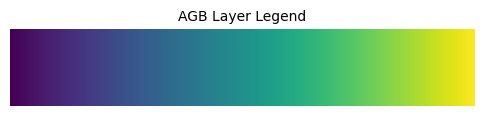

In [88]:
# AGB values range 0-600, so gradient_max = 601
plot_colormap(601, "AGB Layer Legend",'viridis')

### Notebook Sharing

Once the processing is complete and the notebook is ready to be shared as a resource, you can follow these steps to ensure it is accessible to a broader audience. The rendered notebook will be designed for demonstration purposes only and will not be executable. This approach is particularly valuable for presenting complex scientific notebooks to a non-technical audience in a clear and understandable way. For this, we use NotebookSharing.space service. Since, this notebook contains interactive visualization maps, it is a good practice to generate an executed version of this notebook before sharing so that the maps and data are embedded in the notebook. For generating an executed notebook, following command needs to be run.

In [90]:
# Generate an executed notebook - <notebook>-executed.ipynb
# Use the kernel corresponding to the current environment, python3 in this case

#!python -m nbconvert <notebook>.ipynb --to ipynb --stdout --execute > <notebook>-executed.ipynb -ExecutePreprocessor.kernel_name=python3

### Upload the Notebook

After executing the above cell, you can find the executed notebook in the same directory with the name `big-EO-viz-executed.ipynb`. You can upload this notebook to the NotebookSharing.space and get an unique URL for sharing. 